<a href="https://colab.research.google.com/github/nakedrishiii/24_Rishi_Asopa_D2/blob/main/polynomial_regression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [64]:
X = 9 * np.random.rand(350, 4) - 6
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(350, 4)

# y = 0.8x^2 + 0.9x + 2

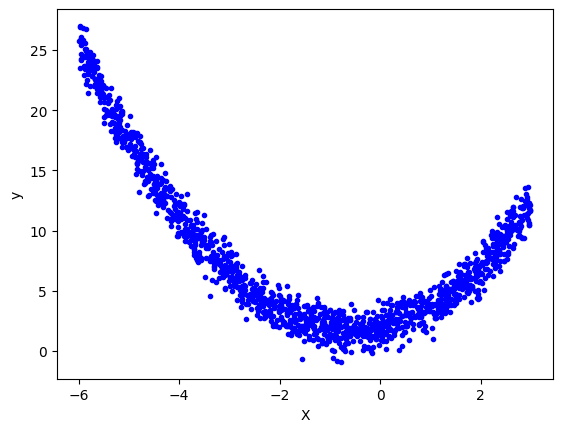

In [65]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [66]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.6,random_state=3)

In [67]:
# Applying linear regression
lr = LinearRegression()

In [68]:
lr.fit(X_train,y_train)

LinearRegression()

In [69]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.36472055099308887

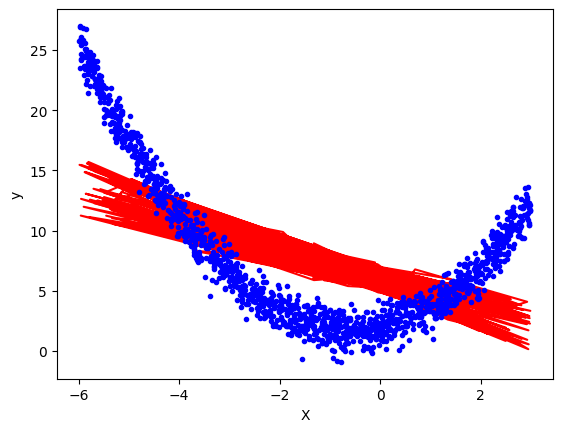

In [70]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [71]:
# Applying Polynomial Linear Regression
# degree 4
poly = PolynomialFeatures(degree=4,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [72]:
print(X_train[0])
print(X_train_trans[0])

[-0.7154084   1.82314507 -4.48655045 -1.86153412]
[ 1.00000000e+00 -7.15408401e-01  1.82314507e+00 -4.48655045e+00
 -1.86153412e+00  5.11809180e-01 -1.30429330e+00  3.20971588e+00
  1.33175715e+00  3.32385795e+00 -8.17963234e+00 -3.39384676e+00
  2.01291349e+01  8.35186675e+00  3.46530929e+00 -3.66152587e-01
  9.33102385e-01 -2.29625771e+00 -9.52750253e-01 -2.37791590e+00
  5.85177769e+00  2.42798648e+00 -1.44005522e+01 -5.97499564e+00
 -2.47911138e+00  6.05987525e+00 -1.49126564e+01 -6.18747500e+00
  3.66983332e+01  1.52266647e+01  6.31776155e+00 -9.03103794e+01
 -3.74710715e+01 -1.55472849e+01 -6.45079148e+00  2.61948637e-01
 -6.67549285e-01  1.64276205e+00  6.81605535e-01  1.70118101e+00
 -4.18641092e+00 -1.73700193e+00  1.03022761e+01  4.27456207e+00
  1.77357710e+00 -4.33528566e+00  1.06686397e+01  4.42657159e+00
 -2.62542958e+01 -1.08932839e+01 -4.51977969e+00  6.46088041e+01
  2.68071194e+01  1.11226583e+01  4.61495042e+00  1.10480317e+01
 -2.71879360e+01 -1.12806645e+01  6.6906

In [73]:
# include_bias parameter

In [74]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [75]:
y_pred = lr.predict(X_test_trans)

In [76]:
r2_score(y_test,y_pred)

0.9351588052577484

In [77]:
print(lr.coef_)
print(lr.intercept_)

[[-1.00471541e-13  8.02599443e-01  1.18467959e-01 -1.02214103e-01
  -2.50480205e-01  7.94452716e-01 -2.54726042e-02  1.12905992e-01
  -8.73587366e-02  7.05903401e-02  3.80130429e-02  6.34029558e-02
   5.28415549e-02 -3.91836708e-02 -1.48914642e-02  1.34578964e-02
   1.98458062e-02 -3.06535394e-02  1.26066129e-02 -8.12720011e-03
   3.17676804e-02 -6.26930826e-03  1.44236572e-02 -1.98206591e-02
   4.14665165e-03 -1.81292137e-02  2.73958952e-02  3.67427163e-02
  -3.03955731e-03 -1.27646411e-02 -3.72683699e-03  1.09278490e-02
   3.96361780e-03  1.49349708e-02  5.44287906e-05  1.90751884e-03
   7.04614674e-03 -1.13932078e-02  2.55312974e-03  7.59099991e-04
  -5.66693612e-03 -4.99803486e-05  1.83396115e-03  4.41917293e-03
  -3.62874238e-04 -2.72934992e-03  4.76630793e-03  2.13881479e-03
   8.24469362e-03 -2.78867849e-03 -4.81880963e-03 -2.87223172e-03
   4.42609484e-03 -5.94503579e-03  3.68260528e-03 -5.19439564e-03
   5.38637695e-03  4.13392870e-03 -2.43989173e-03 -1.29229530e-03
   3.54169

In [78]:
X_new=np.linspace(-3, 3, 350 * 4).reshape(350, 4)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

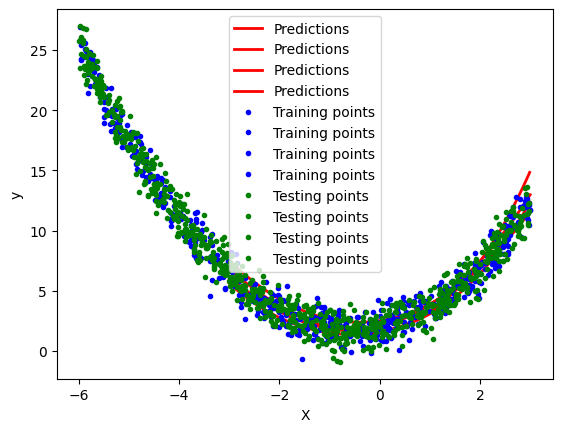

In [79]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [80]:
def polynomial_regression(degree):
    # Generate 1D data for plotting the regression curve
    X_new_plot = np.linspace(-3, 3, 100).reshape(100, 1)

    # The pipeline for training and making predictions
    # We will train this pipeline on a single feature of the original data
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    polynomial_regression_model = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])

    # Fit the model using only the first feature of X and y
    # Assuming the visualization is for the first feature (X[:, 0])
    polynomial_regression_model.fit(X[:, 0].reshape(-1, 1), y[:, 0])

    # Predict using the 1D plotting data
    y_newbig = polynomial_regression_model.predict(X_new_plot)

    plt.plot(X_new_plot, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    # Plot training and testing points for the first feature
    plt.plot(X_train[:, 0], y_train[:, 0], "b.", label='Training points')
    plt.plot(X_test[:, 0], y_test[:, 0], "g.", label='Testing points')
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

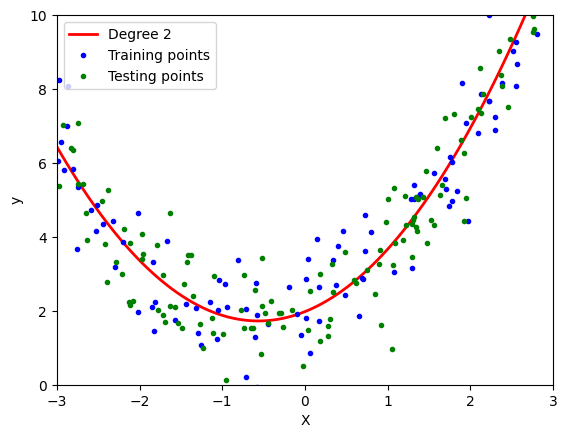

In [81]:
polynomial_regression(2)

In [82]:
poly.powers_

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [2, 0, 0, 0],
       [1, 1, 0, 0],
       [1, 0, 1, 0],
       [1, 0, 0, 1],
       [0, 2, 0, 0],
       [0, 1, 1, 0],
       [0, 1, 0, 1],
       [0, 0, 2, 0],
       [0, 0, 1, 1],
       [0, 0, 0, 2],
       [3, 0, 0, 0],
       [2, 1, 0, 0],
       [2, 0, 1, 0],
       [2, 0, 0, 1],
       [1, 2, 0, 0],
       [1, 1, 1, 0],
       [1, 1, 0, 1],
       [1, 0, 2, 0],
       [1, 0, 1, 1],
       [1, 0, 0, 2],
       [0, 3, 0, 0],
       [0, 2, 1, 0],
       [0, 2, 0, 1],
       [0, 1, 2, 0],
       [0, 1, 1, 1],
       [0, 1, 0, 2],
       [0, 0, 3, 0],
       [0, 0, 2, 1],
       [0, 0, 1, 2],
       [0, 0, 0, 3],
       [4, 0, 0, 0],
       [3, 1, 0, 0],
       [3, 0, 1, 0],
       [3, 0, 0, 1],
       [2, 2, 0, 0],
       [2, 1, 1, 0],
       [2, 1, 0, 1],
       [2, 0, 2, 0],
       [2, 0, 1, 1],
       [2, 0, 0, 2],
       [1, 3, 0, 0],
       [1, 2, 1, 0],
       [1, 2,

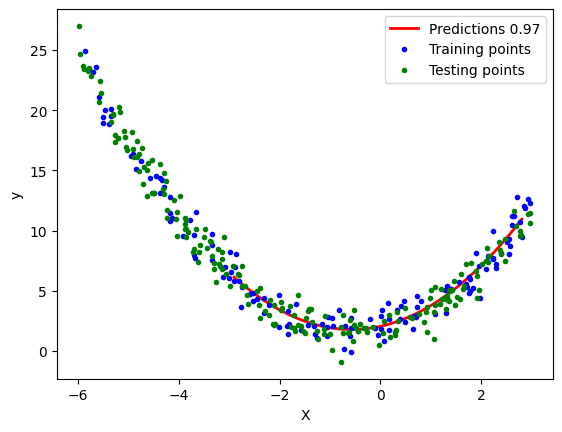

In [83]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

# Use only the first feature of X for training and the first target variable of y
X_train_single_feature = X_train[:, 0].reshape(-1, 1)
X_test_single_feature = X_test[:, 0].reshape(-1, 1)
y_train_single_target = y_train[:, 0]
y_test_single_target = y_test[:, 0]

X_train_trans = poly.fit_transform(X_train_single_feature)
X_test_trans = poly.transform(X_test_single_feature)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans, y_train_single_target)

# Generate new data for plotting the regression curve (1 feature)
X_new_plot = np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new_plot)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new_plot, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test_single_target,y_pred),2)))
plt.plot(X_train_single_feature, y_train_single_target, "b.",label='Training points')
plt.plot(X_test_single_feature, y_test_single_target, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [84]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [85]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [86]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)



In [87]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [88]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [89]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [90]:
print("Input",poly.n_features_in_)
print("Ouput",X_multi_trans.shape[1])
print("Powers\n",poly.powers_)

Input 2
Ouput 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 [

In [91]:
X_multi_trans.shape

(100, 496)

In [92]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [93]:
X_test_multi = poly.transform(final)

In [94]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [95]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()